In [ ]:
# Imports
import pandas as pd
from googleapiclient.discovery import build
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import spacy
import en_core_web_sm

In [ ]:
#KEYS GO HERE
API_KEY = "*"
CSE_ID = "*"

In [ ]:
#Following code from the module for web scraping

def google_search(query, api_key, cse_id, num_results=100):
    service = build("customsearch", "v1", developerKey=api_key)
    results = []
    start_index = 1

    while start_index < num_results:
        response = service.cse().list(
            q=query,
            cx=cse_id,
            start=start_index,
            num=min(num_results - len(results), 10)
        ).execute()

        if "items" in response:
            for item in response['items']:
                results.append({
                    "title": item.get("title"),
                    "link": item.get("link"),
                    "description": item.get("snippet")
                })

        start_index += 10

        if "items" not in response:
            break

    return results

In [ ]:
query = "data science libraries"
results = google_search(query, API_KEY, CSE_ID, num_results=100) #<-- should give us 100 results

for result in results:
    print(f"Title: {result['title']}")
    print(f"URL: {result['link']}")
    print(f"Description: {result['content']}\n")

Title: Does anyone use Python for a Data Science position? If so, what are ...
URL: https://www.reddit.com/r/Python/comments/uorxt5/does_anyone_use_python_for_a_data_science/
Description: May 13, 2022 ... Data science packages · pandas / numpy for data wrangling · scikit-learn for ML models · statsmodels for statistical analysis · pytorch / keras for ...

Title: Top 31 Python Libraries for Data Science in 2026 | DataCamp
URL: https://www.datacamp.com/blog/top-python-libraries-for-data-science
Description: Staple Python Libraries for Data Science · 1. NumPy · 2. Pandas · 3. Polars · 4. Matplotlib · 5. Seaborn · 6. Plotly · 7. Scikit-Learn · 8. Streamlit.

Title: LIBER Data Science in Libraries Working Group - LIBER Europe
URL: https://libereurope.eu/working-group/liber-data-science-in-libraries-working-group/
Description: Oct 1, 2020 ... The LIBER Data Science in Libraries (DSLib) working group explores and promotes library engagement in applying data science and analytical methods in l

In [ ]:
##################################################################### IGNORE EVERYTHING BELOW THIS LINE ##########################################################################

In [6]:
#Dataframe
df1 = pd.DataFrame(results)
df1.head(5)

,title,link,description
0,Does anyone use Python for a Data Science posi...,https://www.reddit.com/r/Python/comments/uorxt...,"May 13, 2022 ... Data science packages · panda..."
1,Top 31 Python Libraries for Data Science in 20...,https://www.datacamp.com/blog/top-python-libra...,Staple Python Libraries for Data Science · 1. ...
2,LIBER Data Science in Libraries Working Group ...,https://libereurope.eu/working-group/liber-dat...,"Oct 1, 2020 ... The LIBER Data Science in Libr..."
3,"Responsible Operations: Data Science, Machine ...",https://www.oclc.org/research/publications/201...,"Suggested citation: Padilla, Thomas. 2019. Res..."
4,Top 20 Python Libraries for Data Science for 2026,https://www.simplilearn.com/top-python-librari...,"Nov 19, 2025 ... TL;DR: The best Python librar..."


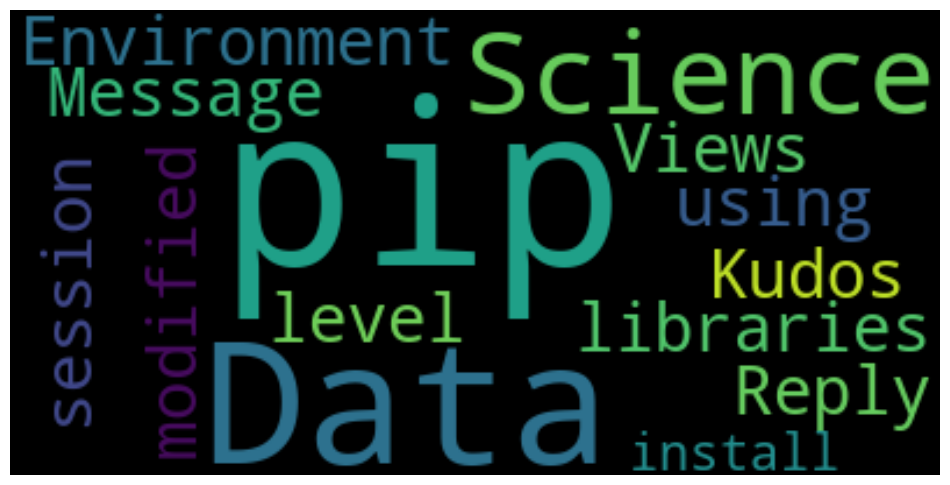

In [7]:
#Create WordCloud from descriptions
wordcloud = WordCloud().generate("description")

# Visualize the word cloud
import matplotlib.pyplot as plt
wordcloud = WordCloud().generate(result["description"])
plt.figure(figsize=(12, 9))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()